# Brain Tumor Segmentation — BraTS 2020: U-Net vs DeepLabv3+

The task is to perform **semantic segmentation of brain tumors** from multimodal MRI scans in the **BraTS 2020** dataset.

Each patient contains four MRI modalities:

* **T1**
* **T1ce / T1Gd**
* **T2**
* **FLAIR**

The segmentation mask uses the original BraTS labels:

* `0` — background
* `1` — NCR/NET: necrotic and non-enhancing tumor core
* `2` — ED: peritumoral edema
* `4` — ET: enhancing tumor

For training, we remap label `4 -> 3`, obtaining four consecutive classes `[0, 1, 2, 3]`.

In this notebook, we compare two 2D semantic segmentation architectures:

* **U-Net**, used as our baseline model
* **DeepLabv3+**, used as a more advanced architecture to investigate whether its multi-scale feature extraction and contextual information can improve tumor segmentation performance

Both models receive the four MRI modalities as **four input channels** and predict a multiclass segmentation mask for each axial slice.

The main objective is to **compare U-Net and DeepLabv3+ under the same experimental setting**, evaluating their segmentation performance on the BraTS 2020 dataset and determining whether DeepLabv3+ provides measurable improvements over the U-Net baseline.


> **Important:** the official BraTS 2020 validation set does not provide public ground-truth segmentations.  
> For this reason, train/validation/test are obtained by splitting the **annotated training patients**, at patient level. This avoids data leakage between slices belonging to the same patient.

## Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["KERAS_BACKEND"] = "tensorflow"
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf
import matplotlib.pyplot as plt
import gdown
import pandas as pd

- `nibabel` to read NIfTI (`.nii` / `.nii.gz`) MRI volumes;
- `kagglehub` to download the Kaggle dataset directly from Colab.

In [2]:
!pip -q install nibabel kagglehub

In [3]:
import nibabel as nib
import kagglehub

## Download dataset

In [4]:
# ============================================================
# 1. DATASET DOWNLOAD
# ============================================================

DATASET_HANDLE = "talhaumar/brats2020-correct-dataset-training-validation"

try:
    DATASET_PATH = kagglehub.dataset_download(DATASET_HANDLE)
except Exception as e:
    print("Kaggle download requires authentication.")
    print("You can authenticate with your Kaggle API token.")
    print("Original error:", e)

    kagglehub.login()
    DATASET_PATH = kagglehub.dataset_download(DATASET_HANDLE)

print("Dataset path:", DATASET_PATH)

100%|██████████| 4.16G/4.16G [00:46<00:00, 96.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/talhaumar/brats2020-correct-dataset-training-validation/versions/1


## Runtime / GPU check

In [5]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print("\nGPU details:")
        print(tf.config.experimental.get_device_details(gpu))
else:
    print("\nNo GPU found. In Colab select Runtime -> Change runtime type -> GPU.")

TensorFlow version: 2.20.0
Keras version: 3.13.2

GPU details:
{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


# Dataset analysis



In [6]:
# ============================================================
# DATASET DISCOVERY
# ============================================================

def strip_nii_extension(path):
    if path.endswith(".nii.gz"):
        return path[:-7]
    if path.endswith(".nii"):
        return path[:-4]
    return path


def find_nii(prefix):
    candidates = [
        prefix + ".nii.gz",
        prefix + ".nii",
    ]

    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate

    return None


def discover_training_cases(dataset_root):
    seg_files = []

    for root, _, files in os.walk(dataset_root):
        for filename in files:
            if filename.endswith("_seg.nii") or filename.endswith("_seg.nii.gz"):
                seg_files.append(os.path.join(root, filename))

    cases = []

    for seg_path in sorted(seg_files):
        seg_base = strip_nii_extension(seg_path)

        if not seg_base.endswith("_seg"):
            continue

        prefix = seg_base[:-4]

        case = {
            "name": os.path.basename(prefix),
            "t1": find_nii(prefix + "_t1"),
            "t1ce": find_nii(prefix + "_t1ce"),
            "t2": find_nii(prefix + "_t2"),
            "flair": find_nii(prefix + "_flair"),
            "seg": seg_path,
        }

        required = ["t1", "t1ce", "t2", "flair", "seg"]

        if all(case[key] is not None for key in required):
            cases.append(case)

    return cases


cases = discover_training_cases(DATASET_PATH)

print("Annotated training cases found:", len(cases))

if len(cases) == 0:
    raise RuntimeError(
        "No annotated BraTS cases were found. "
        "Inspect DATASET_PATH and verify that the Kaggle download completed correctly."
    )

print("\nExample case:")
for key, value in cases[0].items():
    print(f"{key:>6}: {value}")

Annotated training cases found: 369

Example case:
  name: BraTS20_Training_001
    t1: /root/.cache/kagglehub/datasets/talhaumar/brats2020-correct-dataset-training-validation/versions/1/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii
  t1ce: /root/.cache/kagglehub/datasets/talhaumar/brats2020-correct-dataset-training-validation/versions/1/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii
    t2: /root/.cache/kagglehub/datasets/talhaumar/brats2020-correct-dataset-training-validation/versions/1/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii
 flair: /root/.cache/kagglehub/datasets/talhaumar/brats2020-correct-dataset-training-validation/versions/1/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii
   

## Inspect one subject

In [7]:
# ============================================================
# BASIC DATA INSPECTION
# ============================================================
example_case = cases[0]

for modality in ["t1", "t1ce", "t2", "flair", "seg"]:
    image = nib.load(example_case[modality])
    print(
        f"{modality:>5} | shape = {image.shape} | "
        f"dtype = {image.get_data_dtype()}"
    )

example_seg = np.asarray(nib.load(example_case["seg"]).dataobj)

print("\nUnique segmentation labels:", np.unique(example_seg))
print("Number of voxels:", example_seg.size)
print("Tumor voxels:", np.sum(example_seg > 0))
print("Tumor percentage:", 100 * np.mean(example_seg > 0), "%")

   t1 | shape = (240, 240, 155) | dtype = int16
 t1ce | shape = (240, 240, 155) | dtype = int16
   t2 | shape = (240, 240, 155) | dtype = int16
flair | shape = (240, 240, 155) | dtype = int16
  seg | shape = (240, 240, 155) | dtype = uint8

Unique segmentation labels: [0 1 2 4]
Number of voxels: 8928000
Tumor voxels: 211979
Tumor percentage: 2.3743167562724015 %


## Visualize modalities and ground truth

Selected axial slice: 38


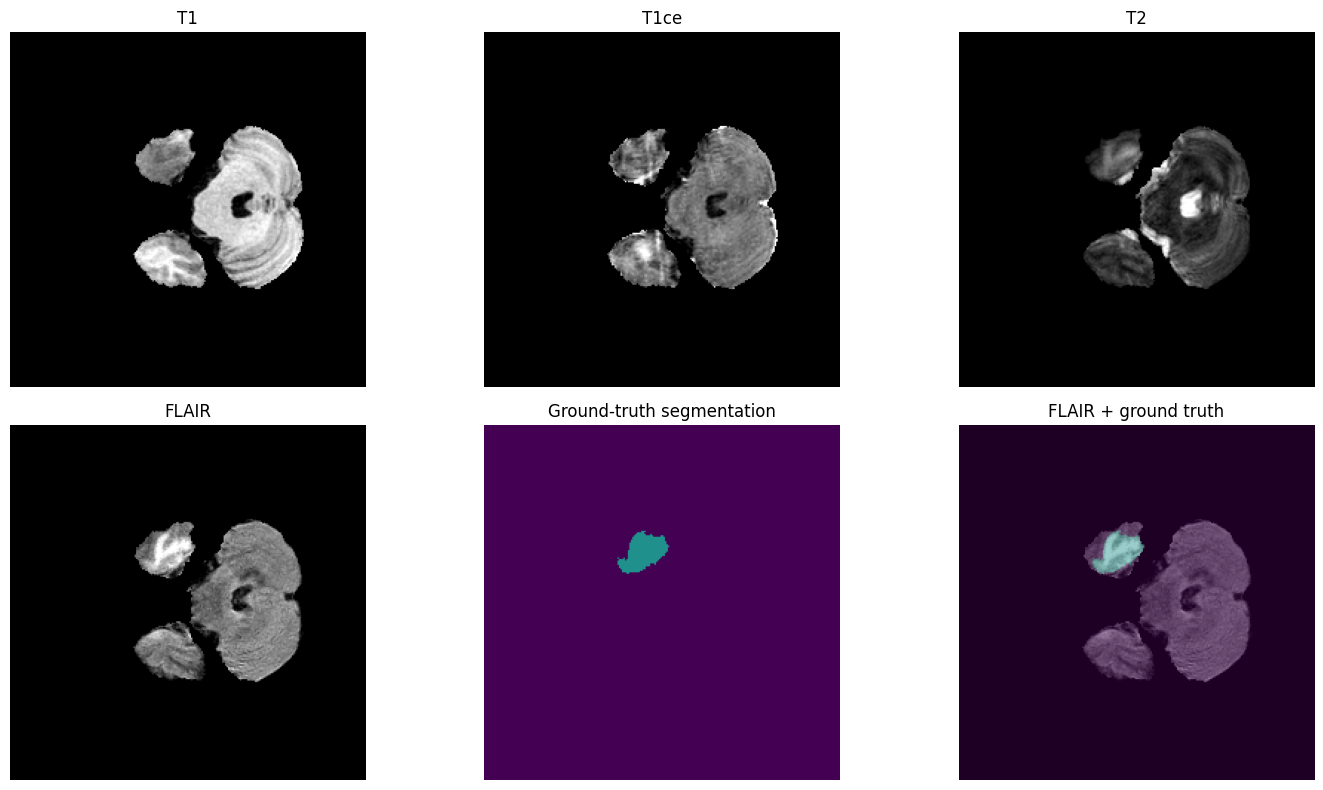

In [8]:
# ============================================================
# DATASET VISUALIZATION
# ============================================================
SELECTED_SLICE = 38  # the slice goes from 0 to 155. They rappresent a 2D plane of the 3D scan.

def minmax_for_display(image):
    image = image.astype(np.float32)
    nonzero = image[image != 0]

    if len(nonzero) == 0:
        return image

    low = np.percentile(nonzero, 1)
    high = np.percentile(nonzero, 99)

    image = np.clip(image, low, high)
    image = (image - low) / (high - low + 1e-8)

    return image


def load_slice(path, z):
    nii = nib.load(path)
    return np.asarray(nii.dataobj[:, :, SELECTED_SLICE], dtype=np.float32)


# Select the axial slice containing the largest tumor area.
seg_volume = np.asarray(nib.load(example_case["seg"]).dataobj)
tumor_area_per_slice = np.sum(seg_volume > 0, axis=(0, 1))
z = int(np.argmax(tumor_area_per_slice))

print("Selected axial slice:", SELECTED_SLICE)

t1 = minmax_for_display(load_slice(example_case["t1"], SELECTED_SLICE))
t1ce = minmax_for_display(load_slice(example_case["t1ce"], SELECTED_SLICE))
t2 = minmax_for_display(load_slice(example_case["t2"], SELECTED_SLICE))
flair = minmax_for_display(load_slice(example_case["flair"], SELECTED_SLICE))
seg = seg_volume[:, :, SELECTED_SLICE]

plt.figure(figsize=(15, 8))

images = [t1, t1ce, t2, flair]
titles = ["T1", "T1ce", "T2", "FLAIR"]

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(seg, cmap="viridis", vmin=0, vmax=4)
plt.title("Ground-truth segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(flair, cmap="gray")
plt.imshow(seg, cmap="viridis", alpha=0.45, vmin=0, vmax=4)
plt.title("FLAIR + ground truth")
plt.axis("off")

plt.tight_layout()
plt.show()

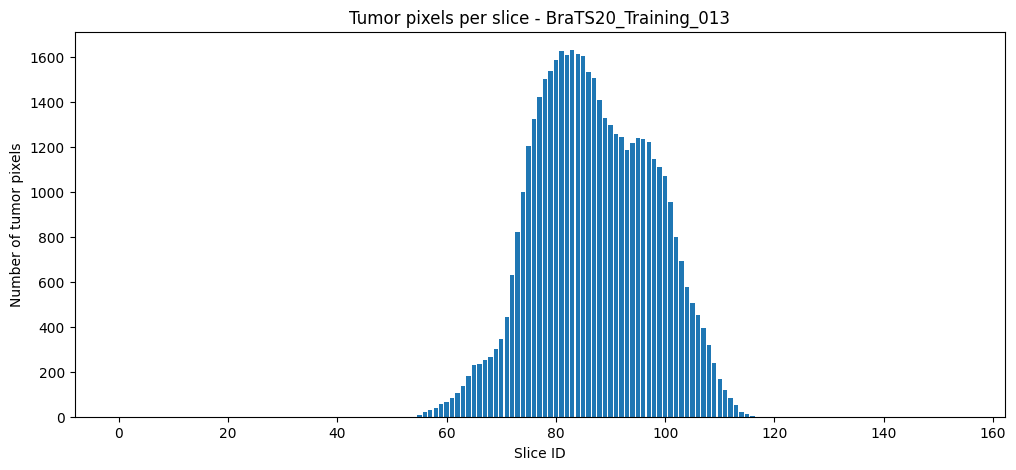

In [9]:
# ============================================================
# TUMOR PIXELS PER SLICE
# ============================================================

PATIENT_ID = 12

case = cases[PATIENT_ID]

seg_volume = np.asarray(
    nib.load(case["seg"]).dataobj,
    dtype=np.uint8
)

tumor_pixels_per_slice = np.sum(
    seg_volume > 0,
    axis=(0, 1)
)

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(seg_volume.shape[2]),
    tumor_pixels_per_slice
)

plt.title(f"Tumor pixels per slice - {case['name']}")
plt.xlabel("Slice ID")
plt.ylabel("Number of tumor pixels")

plt.show()

Distribution shape: (369, 155)


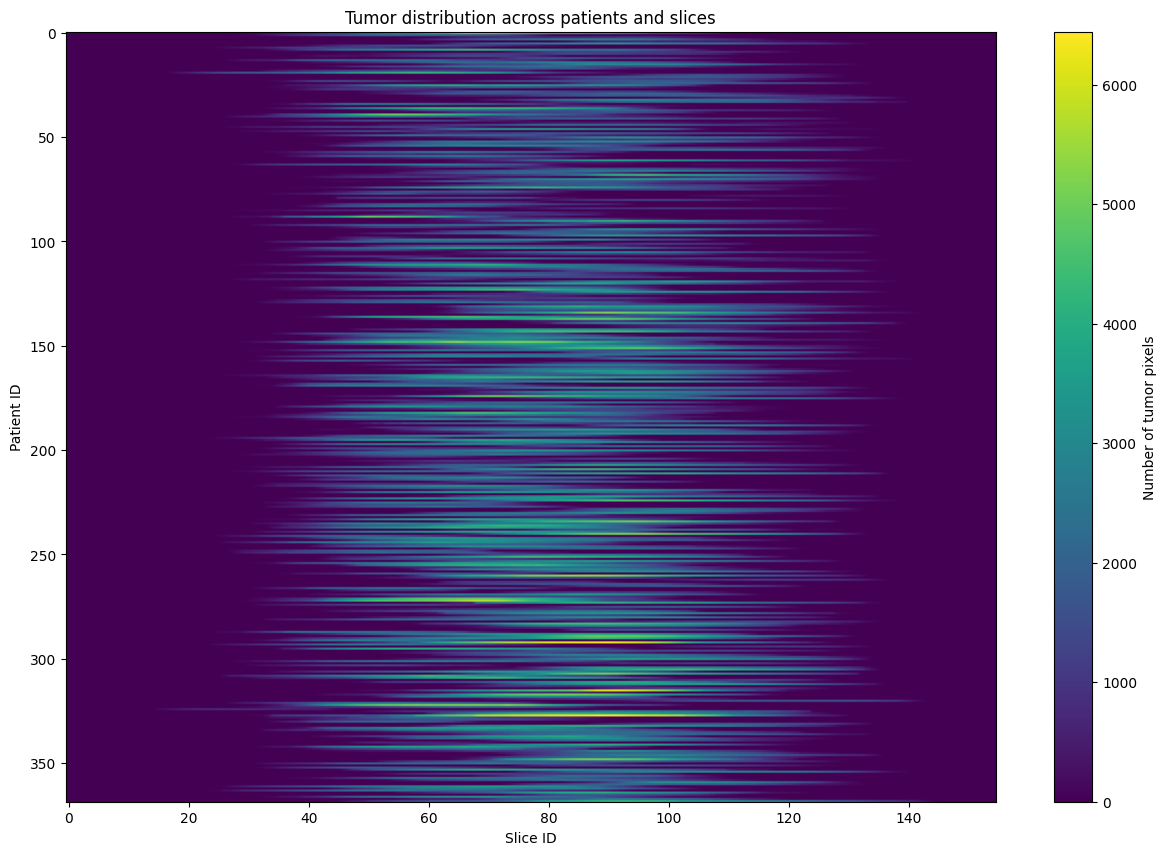

In [10]:
# ============================================================
# TUMOR DISTRIBUTION ACROSS ALL PATIENTS
# ============================================================

tumor_distribution = []

for i, case in enumerate(cases):

    seg_volume = np.asarray(
        nib.load(case["seg"]).dataobj,
        dtype=np.uint8
    )

    # Number of tumor pixels in every slice
    tumor_pixels_per_slice = np.sum(
        seg_volume > 0,
        axis=(0, 1)
    )

    tumor_distribution.append(tumor_pixels_per_slice)

tumor_distribution = np.asarray(tumor_distribution)

plt.figure(figsize=(15, 10))

plt.imshow(
    tumor_distribution,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(
    label="Number of tumor pixels"
)

plt.xlabel("Slice ID")
plt.ylabel("Patient ID")

plt.title(
    "Tumor distribution across patients and slices"
)

print("Distribution shape:", tumor_distribution.shape)
plt.show()

# Train / validation / test split

The split is performed **by patient**, not by individual slice.

If slices from the same MRI volume were randomly distributed across train and test, the evaluation would be artificially optimistic because neighboring slices are highly correlated.

In [11]:
# ============================================================
# 5. PATIENT-LEVEL SPLIT
# ============================================================

SEED = 42
keras.utils.set_random_seed(SEED)

rng = np.random.default_rng(SEED)

indices = np.arange(len(cases))
rng.shuffle(indices)

n_total = len(indices)
n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_cases = [cases[i] for i in indices[:n_train]]
val_cases = [cases[i] for i in indices[n_train:n_train + n_val]]
test_cases = [cases[i] for i in indices[n_train + n_val:]]

print("Train cases:", len(train_cases))
print("Validation cases:", len(val_cases))
print("Test cases:", len(test_cases))
print("Total:", len(train_cases) + len(val_cases) + len(test_cases))

Train cases: 295
Validation cases: 36
Test cases: 38
Total: 369


# Preprocessing

For each selected axial slice:

1. load T1, T1ce, T2 and FLAIR;
2. normalize each modality using z-score normalization on non-zero brain pixels;
3. stack the four modalities into an `(H, W, 4)` tensor;
4. resize to `128 x 128`;
5. resize the segmentation mask with nearest-neighbor interpolation;
6. remap the original BraTS label `4` to class index `3`.


In [12]:
# ============================================================
# PREPROCESSING SETTINGS
# ============================================================

IMG_SIZE = 128   # Original is 240x240
N_CHANNELS = 4   # Background , Edema , ...
N_CLASSES = 4    # T1,T1ce, T2 , Flair
BATCH_SIZE = 8

first_shape = nib.load(cases[0]["seg"]).shape
DEPTH = first_shape[2]

SLICE_IDS = [x for x in range(20,140)] # The range 20-140 is based on visualization above
SLICES_PER_CASE = len(SLICE_IDS)
print("Original volume shape:", first_shape)
print("Selected slices:", SLICE_IDS)
print("Slide per case : " , SLICES_PER_CASE)

Original volume shape: (240, 240, 155)
Selected slices: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]
Slide per case :  120


In [13]:
def normalize_mri_slice(image):
    image = image.astype(np.float32)

    brain = image != 0

    if np.any(brain):
        mean = image[brain].mean()
        std = image[brain].std()

        image[brain] = (image[brain] - mean) / (std + 1e-8)

        # Limit extreme outliers.
        image = np.clip(image, -5.0, 5.0)

    return image


def remap_mask(mask):
    mask = mask.astype(np.uint8).copy()

    # Original BraTS labels: 0, 1, 2, 4
    # Keras classes:          0, 1, 2, 3
    mask[mask == 4] = 3

    return mask


def preprocess_slice(modality_slices, mask):
    # Stack T1, T1ce, T2, FLAIR.
    x = np.stack(
        [normalize_mri_slice(img) for img in modality_slices],
        axis=-1
    )

    x = tf.image.resize(
        x,
        (IMG_SIZE, IMG_SIZE),
        method="bilinear"
    ).numpy()

    mask = tf.image.resize(
        mask[..., None],
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    ).numpy()[..., 0]

    mask = remap_mask(mask)

    return x.astype(np.float32), mask.astype(np.uint8)

## Keras `PyDataset`

In [14]:
# ============================================================
# DATA GENERATOR
# ============================================================

class BratsSliceDataset(PyDataset):
    def __init__(
        self,
        cases,       # Patient list
        slice_ids,   # Slide list
        batch_size=8,
        shuffle_cases=False,
        augment=False,
        seed=42,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.cases = list(cases)
        self.slice_ids = np.asarray(slice_ids, dtype=int)
        self.batch_size = batch_size
        self.shuffle_cases = shuffle_cases
        self.augment = augment
        self.rng = np.random.default_rng(seed)

        self.case_order = np.arange(len(self.cases))

        # Lightweight cache: keep NIfTI handles for the most recently used case.
        self._cached_case_name = None
        self._cached_handles = None

        self._build_batches()

    def _build_batches(self):
        self.batches = []

        for case_idx in self.case_order:
            for start in range(0, len(self.slice_ids), self.batch_size):
                batch_slices = self.slice_ids[start:start + self.batch_size]
                self.batches.append((case_idx, batch_slices))

    def __len__(self):
        return len(self.batches)

    def _get_handles(self, case):
        if self._cached_case_name != case["name"]:
            self._cached_handles = {
                "t1": nib.load(case["t1"]),
                "t1ce": nib.load(case["t1ce"]),
                "t2": nib.load(case["t2"]),
                "flair": nib.load(case["flair"]),
                "seg": nib.load(case["seg"]),
            }

            self._cached_case_name = case["name"]

        return self._cached_handles

    def __getitem__(self, batch_idx):
        case_idx, z_values = self.batches[batch_idx]

        case = self.cases[case_idx]
        handles = self._get_handles(case)

        x_batch = []
        y_batch = []

        for z in z_values:
            modality_slices = [
                np.asarray(handles["t1"].dataobj[:, :, z], dtype=np.float32),
                np.asarray(handles["t1ce"].dataobj[:, :, z], dtype=np.float32),
                np.asarray(handles["t2"].dataobj[:, :, z], dtype=np.float32),
                np.asarray(handles["flair"].dataobj[:, :, z], dtype=np.float32),
            ]

            mask = np.asarray(
                handles["seg"].dataobj[:, :, z],
                dtype=np.uint8
            )

            x, y = preprocess_slice(modality_slices, mask)

            # Very simple augmentation for the training set.
            if self.augment and self.rng.random() < 0.5:
                x = np.flip(x, axis=1).copy()
                y = np.flip(y, axis=1).copy()

            x_batch.append(x)
            y_batch.append(y)

        return (
            np.stack(x_batch).astype(np.float32),
            np.stack(y_batch).astype(np.uint8)
        )

    def on_epoch_end(self):
        if self.shuffle_cases:
            self.rng.shuffle(self.case_order)
            self._build_batches()

In [15]:
train_generator = BratsSliceDataset(
    train_cases,
    SLICE_IDS,
    batch_size=BATCH_SIZE,
    shuffle_cases=True,
    augment=True,
    seed=SEED,
    workers=1,
    use_multiprocessing=False,
    max_queue_size=2
)

val_generator = BratsSliceDataset(
    val_cases,
    SLICE_IDS,
    batch_size=BATCH_SIZE,
    shuffle_cases=False,
    augment=False,
    seed=SEED,
    workers=1,
    use_multiprocessing=False,
    max_queue_size=2
)

test_generator = BratsSliceDataset(
    test_cases,
    SLICE_IDS,
    batch_size=BATCH_SIZE,
    shuffle_cases=False,
    augment=False,
    seed=SEED,
    workers=1,
    use_multiprocessing=False,
    max_queue_size=2
)

print("Train batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Test batches:", len(test_generator))

Train batches: 4425
Validation batches: 540
Test batches: 570


## Inspect a preprocessed batch

In [16]:
ID = 20        # from 0 to len(train_generator)
BATCH_ID = 6  # from 0 to BATCH_SIZE


x_batch, y_batch = train_generator[ID]

print("Input batch shape:", x_batch.shape)
print("Target batch shape:", y_batch.shape)
print("Input dtype:", x_batch.dtype)
print("Target dtype:", y_batch.dtype)
print("Target classes:", np.unique(y_batch))

Input batch shape: (8, 128, 128, 4)
Target batch shape: (8, 128, 128)
Input dtype: float32
Target dtype: uint8
Target classes: [0 1 2 3]


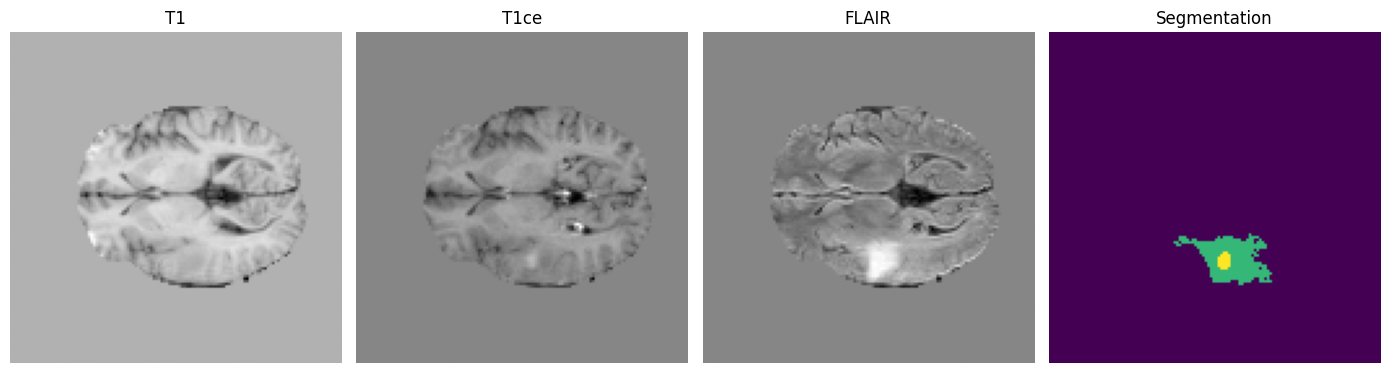

In [17]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_batch[BATCH_ID, :, :, 0], cmap="gray")
plt.title("T1")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x_batch[BATCH_ID, :, :, 1], cmap="gray")
plt.title("T1ce")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(x_batch[BATCH_ID, :, :, 3], cmap="gray")
plt.title("FLAIR")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(y_batch[BATCH_ID], cmap="viridis", vmin=0, vmax=3)
plt.title("Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

# Loss and training metrics

A pure categorical cross-entropy is affected by the severe class imbalance.

We therefore combine:

- **Sparse Categorical Cross-Entropy**
- **soft Dice loss** over the three tumor classes

During training we also report:

- mean tumor Dice;
- pixel accuracy.

The final evaluation later computes the clinically more interpretable BraTS regions:

- **ET** — enhancing tumor;
- **TC** — tumor core;
- **WT** — whole tumor.

In [18]:
# ============================================================
# SEGMENTATION METRICS
# ============================================================

REGIONS = {
    # After remapping label 4 -> 3.
    "ET": lambda m: m == 3,
    "TC": lambda m: np.isin(m, [1, 3]),
    "WT": lambda m: m > 0,
}


def evaluate_predictions(generator, predict_fn, max_batches=None):
    stats = {
        name: {
            "intersection": 0,
            "pred_sum": 0,
            "true_sum": 0,
            "union": 0
        }
        for name in REGIONS
    }

    correct_pixels = 0
    total_pixels = 0

    n_batches = len(generator)

    if max_batches is not None:
        n_batches = min(n_batches, max_batches)

    for i in range(n_batches):
        print(
            f"\rEvaluating batch {i + 1}/{n_batches}",
            end="",
            flush=True
        )

        x, y_true = generator[i]
        y_pred = predict_fn(x, y_true)

        correct_pixels += np.sum(y_pred == y_true)
        total_pixels += y_true.size

        for name, region_fn in REGIONS.items():
            true_region = region_fn(y_true)
            pred_region = region_fn(y_pred)

            intersection = np.logical_and(
                true_region,
                pred_region
            ).sum()

            union = np.logical_or(
                true_region,
                pred_region
            ).sum()

            stats[name]["intersection"] += intersection
            stats[name]["pred_sum"] += pred_region.sum()
            stats[name]["true_sum"] += true_region.sum()
            stats[name]["union"] += union

    print()

    results = {}

    for name, s in stats.items():
        dice = (
            2.0 * s["intersection"] /
            (s["pred_sum"] + s["true_sum"] + 1e-8)
        )

        iou = (
            s["intersection"] /
            (s["union"] + 1e-8)
        )

        results[f"{name}_dice"] = float(dice)
        results[f"{name}_iou"] = float(iou)

    results["mean_dice"] = float(
        np.mean([results[f"{name}_dice"] for name in REGIONS])
    )

    results["mean_iou"] = float(
        np.mean([results[f"{name}_iou"] for name in REGIONS])
    )

    results["pixel_accuracy"] = float(
        correct_pixels / (total_pixels + 1e-8)
    )

    return results


def print_metrics(metrics, title="Metrics"):
    print("\n" + title)
    print("-" * len(title))

    for key, value in metrics.items():
        print(f"{key:>16}: {value:.4f}")

In [19]:
# ============================================================
# LOSS + KERAS METRICS
# ============================================================

cce = keras.losses.SparseCategoricalCrossentropy()


def soft_dice_loss(y_true, y_pred, smooth=1e-5):
    y_true = tf.cast(y_true, tf.int32)

    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(
        y_true,
        depth=N_CLASSES,
        dtype=tf.float32
    )

    # Exclude background channel.
    y_true_tumor = y_true[..., 1:]
    y_pred_tumor = y_pred[..., 1:]

    axes = (0, 1, 2)

    intersection = tf.reduce_sum(
        y_true_tumor * y_pred_tumor,
        axis=axes
    )

    denominator = tf.reduce_sum(
        y_true_tumor + y_pred_tumor,
        axis=axes
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return 1.0 - tf.reduce_mean(dice)


def combined_loss(y_true, y_pred):
    return cce(y_true, y_pred) + soft_dice_loss(y_true, y_pred)


def mean_tumor_dice(y_true, y_pred, smooth=1e-5):
    y_true = tf.cast(y_true, tf.int32)

    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(
        y_true,
        depth=N_CLASSES,
        dtype=tf.float32
    )

    y_pred = tf.one_hot(
        tf.argmax(y_pred, axis=-1),
        depth=N_CLASSES,
        dtype=tf.float32
    )

    y_true = y_true[..., 1:]
    y_pred = y_pred[..., 1:]

    axes = (0, 1, 2)

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=axes
    )

    denominator = tf.reduce_sum(
        y_true + y_pred,
        axis=axes
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return tf.reduce_mean(dice)

# U-Net architecture (2D)

We define a **2D U-Net** adapted to the four MRI modalities. The model follows Ronneberger et al. (2015): a contracting encoder progressively extracts high-level features through convolutional blocks and downsampling operations, while a symmetric expanding decoder restores the original spatial resolution. **Skip connections** between corresponding encoder and decoder levels transfer high-resolution features, helping preserve spatial information and improve tumour boundary localization.
This architecture is defined as baseline, the goal of this project is to obtain a better result using a different architecture based on the newer.

Reference: Ronneberger, O., Fischer, P., Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI, pp. 234–241.


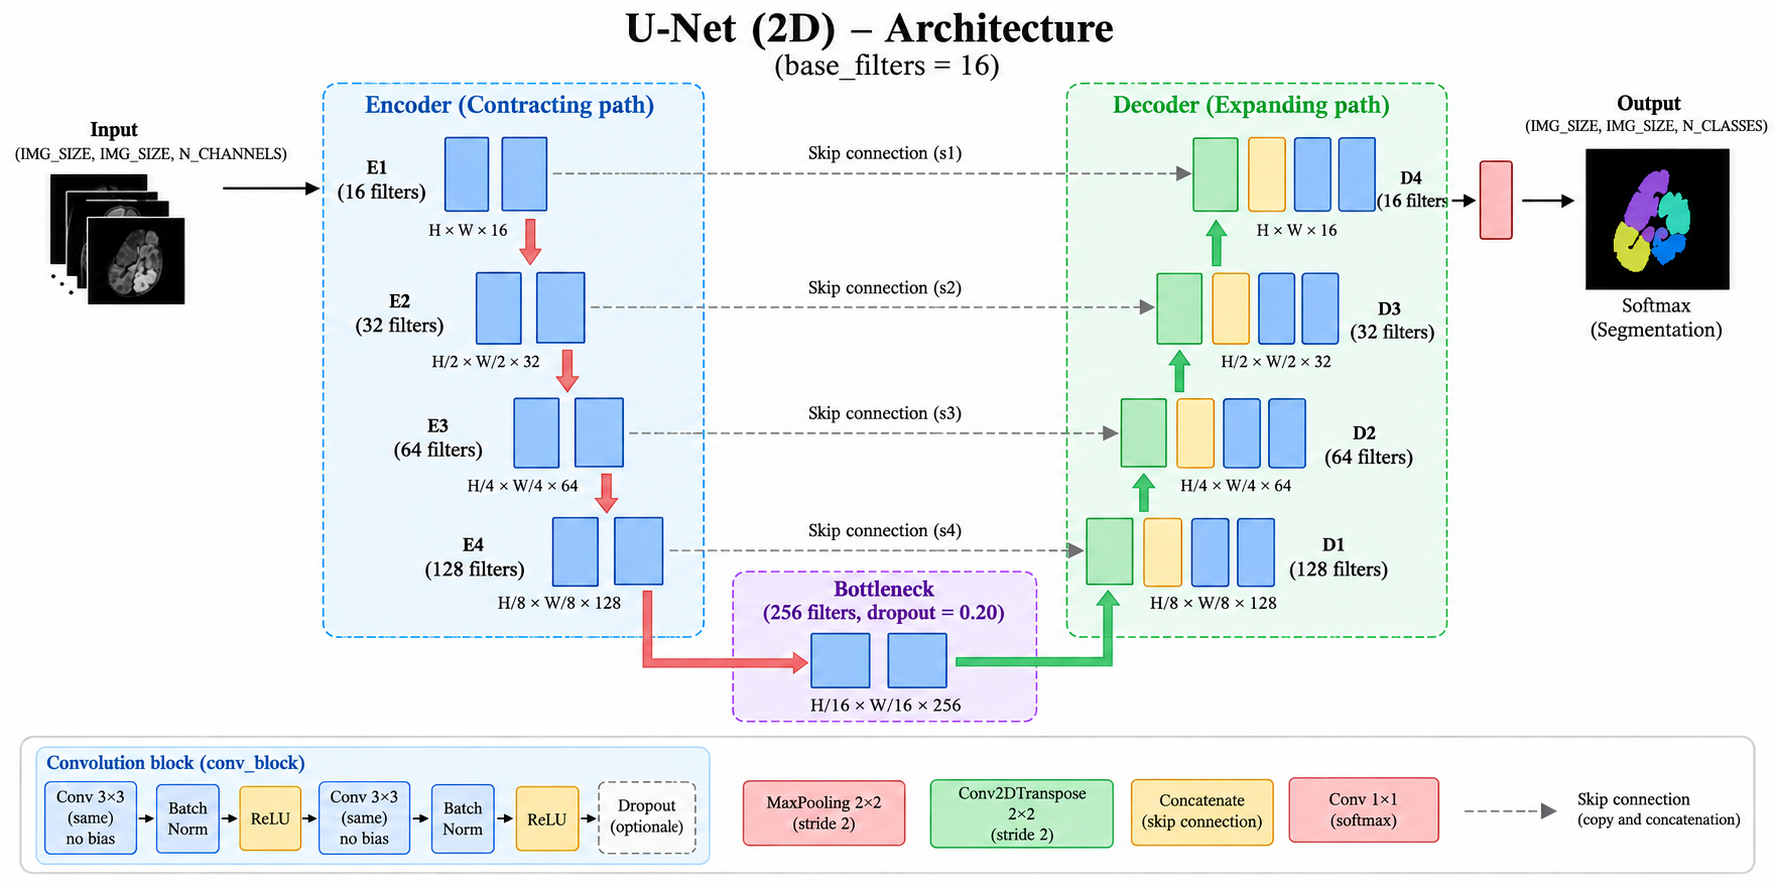

In [20]:
# ============================================================
# U-NET BLOCKS
# ============================================================

def conv_block(x, filters, dropout=0.0):
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    return x


def encoder_block(x, filters):
    skip = conv_block(x, filters)
    pooled = layers.MaxPooling2D(pool_size=2)(skip)

    return skip, pooled


def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size=2,
        strides=2,
        padding="same"
    )(x)

    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)

    return x

In [21]:
# ============================================================
# FULL U-NET
# ============================================================

def build_unet(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    n_classes=N_CLASSES,
    base_filters=16
):
    inputs = layers.Input(
        shape=input_shape,
        name="multimodal_mri"
    )

    # Encoder.
    s1, p1 = encoder_block(inputs, base_filters)
    s2, p2 = encoder_block(p1, base_filters * 2)
    s3, p3 = encoder_block(p2, base_filters * 4)
    s4, p4 = encoder_block(p3, base_filters * 8)

    # Bottleneck.
    b = conv_block(
        p4,
        base_filters * 16,
        dropout=0.20
    )

    # Decoder.
    d1 = decoder_block(b, s4, base_filters * 8)
    d2 = decoder_block(d1, s3, base_filters * 4)
    d3 = decoder_block(d2, s2, base_filters * 2)
    d4 = decoder_block(d3, s1, base_filters)

    outputs = layers.Conv2D(
        n_classes,
        kernel_size=1,
        activation="softmax",
        name="segmentation"
    )(d4)

    return models.Model(
        inputs,
        outputs,
        name="brats_2d_unet"
    )

In [22]:
# ============================================================
# MODEL U-NET DEFINITION
# ============================================================

unet_model = build_unet()
unet_model.summary()
num_params = unet_model.count_params()

print(f"\nTotal parameters: {num_params:,}")
print(f"Trainable parameters: "f"{sum(np.prod(v.shape) for v in unet_model.trainable_weights):,}")

# Shape test.
x_batch, y_batch = train_generator[0]
pred_batch = unet_model(x_batch, training=False)

print("\nInput batch shape: ", x_batch.shape)
print("Target batch shape:", y_batch.shape)
print("Pred batch shape:  ", pred_batch.shape)

# ============================================================
# MODEL U-NET COMPILING
# ============================================================

unet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss,
    metrics=[
        mean_tumor_dice,
        keras.metrics.SparseCategoricalAccuracy(
            name="pixel_accuracy"
        )
    ]
)

Model: "brats_2d_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ multimodal_mri      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        576 │ multimodal_mri[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,304 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,608 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,216 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,432 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]  

 Total params: 1,945,716 (7.42 MB)

 Trainable params: 1,942,772 (7.41 MB)

 Non-trainable params: 2,944 (11.50 KB)


Total parameters: 1,945,716
Trainable parameters: 1,942,772

Input batch shape:  (8, 128, 128, 4)
Target batch shape: (8, 128, 128)
Pred batch shape:   (8, 128, 128, 4)


# DeepLabv3+ architecture (2D)

We now define a **2D DeepLabv3+** adapted to the four MRI modalities. The model follows Chen et al. (ECCV 2018): an Xception-style encoder extracts features at output stride 16, Atrous Spatial Pyramid Pooling (ASPP) captures multi-scale context, and a lightweight decoder combines the ASPP output with low-level features at output stride 4 to refine boundaries.

All convolutions, atrous convolutions, resizing operations and predictions act on 2D axial slices. The input and output interfaces remain unchanged: `(128, 128, 4)` MRI tensors and `(128, 128, 4)` per-pixel class probabilities.

Reference: Chen, L.-C., Zhu, Y., Papandreou, G., Schroff, F., Adam, H. (2018). *Encoder-Decoder with Atrous Separable Convolution for Semantic Image Segmentation*. ECCV, pp. 801-818.

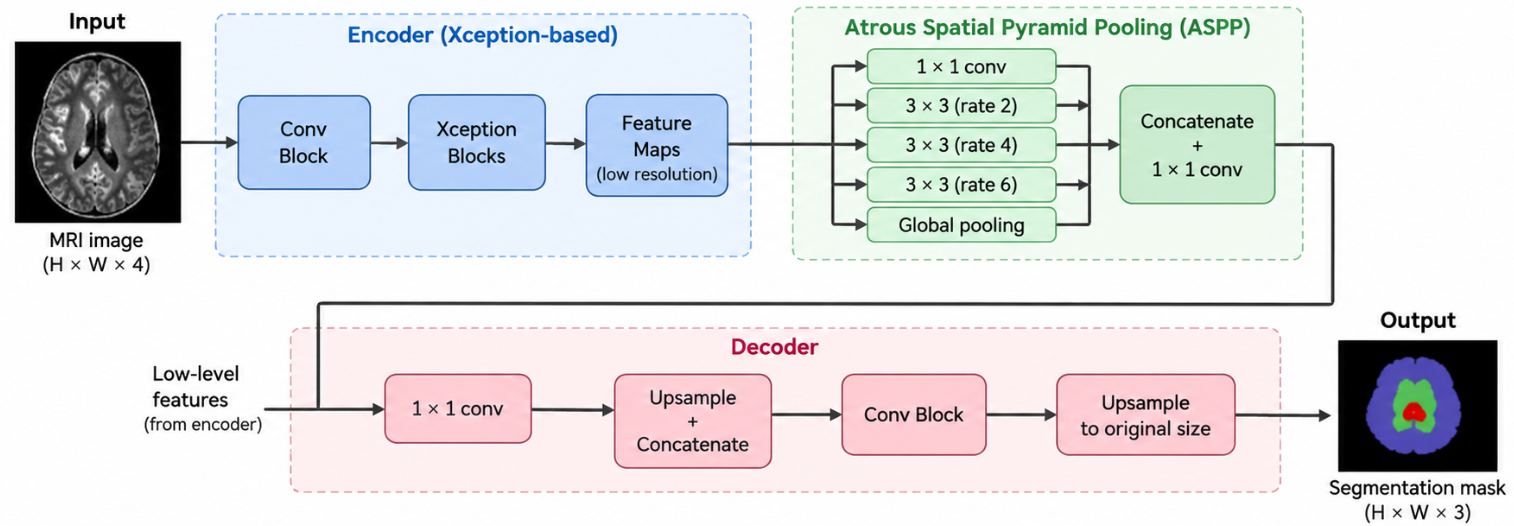

In [34]:
# ============================================================
# DEEPLABV3+ — CONFIGURATION AND BUILDING BLOCKS
# ============================================================

L2_WEIGHT = 5e-5
DROPOUT_RATE = 0.15
GROUPS = 8


# ------------------------------------------------------------
# GROUP NORMALIZATION
# ------------------------------------------------------------

def group_norm(x, name=None):
    return layers.GroupNormalization(
        groups=GROUPS,
        axis=-1,
        epsilon=1e-5,
        name=name
    )(x)


# ------------------------------------------------------------
# STANDARD CONVOLUTION BLOCK
# Conv2D -> GroupNorm -> Swish
# ------------------------------------------------------------

def convolution_block(
    x,
    filters,
    kernel_size=3,
    strides=1,
    dilation_rate=1,
    name=None
):
    x = layers.Conv2D(
        filters,
        kernel_size=kernel_size,
        strides=strides,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=keras.regularizers.l2(L2_WEIGHT),
        name=None if name is None else f"{name}_conv"
    )(x)

    x = group_norm(
        x,
        name=None if name is None else f"{name}_gn"
    )

    x = layers.Activation(
        "swish",
        name=None if name is None else f"{name}_act"
    )(x)

    return x


# ------------------------------------------------------------
# SEPARABLE CONVOLUTION BLOCK
# SeparableConv2D -> GroupNorm -> Swish
# ------------------------------------------------------------

def separable_convolution_block(
    x,
    filters,
    kernel_size=3,
    strides=1,
    dilation_rate=1,
    name=None
):
    x = layers.SeparableConv2D(
        filters,
        kernel_size=kernel_size,
        strides=strides,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False,
        depthwise_initializer="he_normal",
        pointwise_initializer="he_normal",
        depthwise_regularizer=keras.regularizers.l2(L2_WEIGHT),
        pointwise_regularizer=keras.regularizers.l2(L2_WEIGHT),
        name=None if name is None else f"{name}_sepconv"
    )(x)

    x = group_norm(
        x,
        name=None if name is None else f"{name}_gn"
    )

    x = layers.Activation(
        "swish",
        name=None if name is None else f"{name}_act"
    )(x)

    return x


# ------------------------------------------------------------
# SQUEEZE-AND-EXCITATION BLOCK
# Channel attention
# ------------------------------------------------------------

def squeeze_excite_block(x, ratio=8, name="se"):

    channels = int(x.shape[-1])
    reduced_channels = max(channels // ratio, 8)

    se = layers.GlobalAveragePooling2D(
        keepdims=True,
        name=f"{name}_gap"
    )(x)

    se = layers.Conv2D(
        reduced_channels,
        kernel_size=1,
        activation="swish",
        name=f"{name}_reduce"
    )(se)

    se = layers.Conv2D(
        channels,
        kernel_size=1,
        activation="sigmoid",
        name=f"{name}_expand"
    )(se)

    return layers.Multiply(
        name=f"{name}_scale"
    )([x, se])


# ------------------------------------------------------------
# XCEPTION BLOCK
# 2 separable convolutions + residual connection
# ------------------------------------------------------------

def xception_block(
    x,
    filters,
    strides=1,
    dilation_rate=1,
    use_se=False,
    name="xception_block"
):
    residual = x

    # First separable convolution
    x = separable_convolution_block(
        x,
        filters,
        dilation_rate=dilation_rate,
        name=f"{name}_sep1"
    )

    # Second separable convolution
    x = separable_convolution_block(
        x,
        filters,
        strides=strides,
        dilation_rate=dilation_rate,
        name=f"{name}_sep2"
    )

    # Adapt residual when dimensions change
    if strides != 1 or int(residual.shape[-1]) != filters:

        residual = layers.Conv2D(
            filters,
            kernel_size=1,
            strides=strides,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=keras.regularizers.l2(L2_WEIGHT),
            name=f"{name}_shortcut_conv"
        )(residual)

        residual = group_norm(
            residual,
            name=f"{name}_shortcut_gn"
        )

    # Residual connection
    x = layers.Add(
        name=f"{name}_add"
    )([x, residual])

    x = layers.Activation(
        "swish",
        name=f"{name}_out"
    )(x)

    # Optional channel attention
    if use_se:
        x = squeeze_excite_block(
            x,
            ratio=8,
            name=f"{name}_se"
        )

    return x

# ------------------------------------------------------------
# ATROUS SPATIAL PYRAMID POOLING
# Multi-scale feature extraction
# ------------------------------------------------------------

def atrous_spatial_pyramid_pooling(
    x,
    filters=192,
    rates=(2, 4, 6),
    name="aspp"
):

    feature_height = int(x.shape[1])
    feature_width = int(x.shape[2])

    branches = []

    # 1x1 convolution branch
    branches.append(
        convolution_block(
            x,
            filters,
            kernel_size=1,
            name=f"{name}_1x1"
        )
    )

    # Atrous convolution branches
    for rate in rates:
        branches.append(
            separable_convolution_block(
                x,
                filters,
                kernel_size=3,
                dilation_rate=rate,
                name=f"{name}_rate_{rate}"
            )
        )

    # Global context branch
    pooled = layers.GlobalAveragePooling2D(
        keepdims=True,
        name=f"{name}_image_pool"
    )(x)

    pooled = convolution_block(
        pooled,
        filters,
        kernel_size=1,
        name=f"{name}_image_projection"
    )

    pooled = layers.Resizing(
        feature_height,
        feature_width,
        interpolation="bilinear",
        name=f"{name}_image_resize"
    )(pooled)

    branches.append(pooled)

    # Merge all ASPP branches
    x = layers.Concatenate(
        name=f"{name}_concat"
    )(branches)

    x = convolution_block(
        x,
        filters,
        kernel_size=1,
        name=f"{name}_projection"
    )

    # Channel attention
    x = squeeze_excite_block(
        x,
        ratio=8,
        name=f"{name}_se"
    )

    x = layers.SpatialDropout2D(
        DROPOUT_RATE,
        name=f"{name}_dropout"
    )(x)

    return x

In [35]:
# ============================================================
# BUILD DEEPLABV3+
# ============================================================

def build_deeplabv3plus(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    n_classes=N_CLASSES,
    aspp_filters=192
):

    inputs = layers.Input(
        shape=input_shape,
        name="multimodal_mri"
    )

    # ========================================================
    # STEM
    # 128x128 -> 64x64
    # ========================================================

    x = convolution_block(
        inputs,
        32,
        strides=2,
        name="encoder_stem_1"
    )

    stem_features = convolution_block(
        x,
        64,
        name="encoder_stem_2"
    )


    # ========================================================
    # ENCODER
    # ========================================================

    # 64x64 -> 32x32
    low_level_features = xception_block(
        stem_features,
        128,
        strides=2,
        use_se=True,
        name="encoder_entry_1"
    )

    # 32x32 -> 16x16
    x = xception_block(
        low_level_features,
        256,
        strides=2,
        name="encoder_entry_2"
    )

    # Keep output stride = 8
    # 16x16 -> 16x16
    x = xception_block(
        x,
        384,
        strides=1,
        dilation_rate=2,
        use_se=True,
        name="encoder_entry_3"
    )


    # --------------------------------------------------------
    # Middle flow
    # --------------------------------------------------------

    for block_index in range(4):

        x = xception_block(
            x,
            384,
            strides=1,
            dilation_rate=2,
            use_se=(block_index == 3),
            name=f"encoder_middle_{block_index + 1}"
        )


    # ========================================================
    # ASPP
    # ========================================================

    x = atrous_spatial_pyramid_pooling(
        x,
        filters=aspp_filters,
        rates=(2, 4, 6),
        name="aspp"
    )


    # ========================================================
    # DECODER STAGE 1
    # 16x16 -> 32x32
    # ========================================================

    low_height = int(low_level_features.shape[1])
    low_width = int(low_level_features.shape[2])

    x = layers.Resizing(
        low_height,
        low_width,
        interpolation="bilinear",
        name="decoder_aspp_resize"
    )(x)

    low_level_projection = convolution_block(
        low_level_features,
        48,
        kernel_size=1,
        name="decoder_low_level_projection"
    )

    x = layers.Concatenate(
        name="decoder_concat"
    )([
        x,
        low_level_projection
    ])

    x = separable_convolution_block(
        x,
        256,
        name="decoder_sepconv_1"
    )

    x = separable_convolution_block(
        x,
        256,
        name="decoder_sepconv_2"
    )

    x = squeeze_excite_block(
        x,
        ratio=8,
        name="decoder_se"
    )

    x = layers.SpatialDropout2D(
        DROPOUT_RATE,
        name="decoder_dropout"
    )(x)


    # ========================================================
    # DECODER STAGE 2
    # 32x32 -> 64x64
    # ========================================================

    stem_height = int(stem_features.shape[1])
    stem_width = int(stem_features.shape[2])

    x = layers.Resizing(
        stem_height,
        stem_width,
        interpolation="bilinear",
        name="decoder_stem_resize"
    )(x)

    stem_projection = convolution_block(
        stem_features,
        32,
        kernel_size=1,
        name="decoder_stem_projection"
    )

    x = layers.Concatenate(
        name="decoder_stem_concat"
    )([
        x,
        stem_projection
    ])

    x = separable_convolution_block(
        x,
        128,
        name="decoder_refine_1"
    )

    x = separable_convolution_block(
        x,
        128,
        name="decoder_refine_2"
    )

    x = layers.SpatialDropout2D(
        0.10,
        name="decoder_refine_dropout"
    )(x)


    # ========================================================
    # FINAL UPSAMPLING
    # 64x64 -> 128x128
    # ========================================================

    x = layers.Resizing(
        input_shape[0],
        input_shape[1],
        interpolation="bilinear",
        name="decoder_output_resize"
    )(x)

    x = separable_convolution_block(
        x,
        64,
        name="decoder_output_refine"
    )


    # ========================================================
    # SEGMENTATION OUTPUT
    # ========================================================

    outputs = layers.Conv2D(
        n_classes,
        kernel_size=1,
        activation="softmax",
        kernel_regularizer=keras.regularizers.l2(L2_WEIGHT),
        dtype="float32",
        name="segmentation"
    )(x)


    return models.Model(
        inputs=inputs,
        outputs=outputs,
        name="brats_2d_deeplabv3plus_regularized"
    )

In [36]:
# ============================================================
# BUILD AND COMPILE
# ============================================================

# Clear previous Keras state
keras.backend.clear_session()
deeplabv3plus_model = build_deeplabv3plus()
model = deeplabv3plus_model

# Compile
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),

    loss=combined_loss,

    metrics=[
        mean_tumor_dice,

        keras.metrics.SparseCategoricalAccuracy(
            name="pixel_accuracy"
        )
    ]
)

# Training

In [24]:
from keras.src.saving.saving_api import load_weights
# Training settings
EPOCHS = 1
WEIGHTS_URL = "https://drive.google.com/file/d/1k91QoCbnZui53fqXeczM_3pDVvGtamUO/view?usp=drive_link"
WEIGHTS_PATH = "/content/unet_best.weights.h5" # "/kaggle/working/unet_best.weights.h5" --- Kaggle work directory
model = unet_model
execute_train = False  # Set to True to train a new model
load_weights = True # Set to True to start the train from a pretrained model

In [25]:
# DOWNLOAD BEST WEIGHT
if(load_weights):
    WEIGHTS_URL = "https://drive.google.com/file/d/1k91QoCbnZui53fqXeczM_3pDVvGtamUO/view?usp=drive_link"
    WEIGHTS_PATH = "/content/unet_best.weights.h5"
    gdown.download(WEIGHTS_URL,WEIGHTS_PATH,fuzzy=True,quiet=False)  # Weights loaded from drive
    model.load_weights(WEIGHTS_PATH)  # Weights loaded from local path
else:
  print("The model will be trained from scratch - load weights set to" , load_weights)

Downloading...
From: https://drive.google.com/uc?id=1k91QoCbnZui53fqXeczM_3pDVvGtamUO
To: /content/unet_best.weights.h5
100%|██████████| 23.6M/23.6M [00:02<00:00, 11.1MB/s]
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 130 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [26]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        WEIGHTS_PATH,
        monitor="val_mean_tumor_dice",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_mean_tumor_dice",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_mean_tumor_dice",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

In [27]:
# ============================================================
# TRAINING
# ============================================================
if(execute_train):
  history = model.fit(
      train_generator,
      validation_data=val_generator,
      epochs=EPOCHS,
      callbacks=callbacks,
      shuffle=False, # The generator already shuffles patients internally.
      verbose=1
  )
  model.load_weights(WEIGHTS_PATH)
else:
  history = None
  print("Training not started , execute train : ", execute_train)

Training not started , execute train :  False


## Training visualization

In [28]:
# ============================================================
# TRAINING CURVES
# ============================================================
if(history):
  history_dict = history.history

  print("Available history keys:", history_dict.keys())

  epochs = np.arange(
      1,
      len(history_dict["loss"]) + 1
  )

  plt.figure(figsize=(7, 4))

  plt.plot(
      epochs,
      history_dict["loss"],
      marker="o",
      label="Training loss"
  )

  plt.plot(
      epochs,
      history_dict["val_loss"],
      marker="o",
      label="Validation loss"
  )

  plt.title("Loss over epochs")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.grid(True)
  plt.legend()
  plt.show()
  ###############################
  plt.figure(figsize=(7, 4))

  plt.plot(
      epochs,
      history_dict["mean_tumor_dice"],
      marker="o",
      label="Training Dice"
  )

  plt.plot(
      epochs,
      history_dict["val_mean_tumor_dice"],
      marker="o",
      label="Validation Dice"
  )

  plt.title("Mean tumor Dice over epochs")
  plt.xlabel("Epoch")
  plt.ylabel("Dice")
  plt.ylim(0, 1)
  plt.grid(True)
  plt.legend()
  plt.show()
else:
  print("Training not executed in this notebook, skip history visualization")

Training not executed in this notebook, skip history visualization


# Evaluation

The final model is evaluated on patients that were never used during training or validation.

We calculate:

- Dice ET
- Dice TC
- Dice WT
- IoU ET
- IoU TC
- IoU WT
- mean Dice
- mean IoU
- pixel accuracy

The BraTS regions are reconstructed from our remapped classes:

- `ET = class 3` (original label 4)
- `TC = classes 1 + 3`
- `WT = classes 1 + 2 + 3`

In [29]:
# ============================================================
# GENERIC MODEL EVALUATION
# ============================================================

def evaluate_model(model, generator):

    def predictor(x, y_true):
        probabilities = model.predict(
            x,
            verbose=0
        )

        return np.argmax(
            probabilities,
            axis=-1
        ).astype(np.uint8)

    return evaluate_predictions(
        generator,
        predict_fn=predictor
    )

In [30]:
# ============================================================
# TRAINING MODEL EVALUATION
# ============================================================

trained_model_metrics = evaluate_model(
    model,
    test_generator
)

print_metrics(
    trained_model_metrics,
    title="Trained model results"
)

Evaluating batch 570/570

Trained model results
---------------------
         ET_dice: 0.7966
          ET_iou: 0.6619
         TC_dice: 0.8016
          TC_iou: 0.6689
         WT_dice: 0.8828
          WT_iou: 0.7902
       mean_dice: 0.8270
        mean_iou: 0.7070
  pixel_accuracy: 0.9943


# Visual inspection

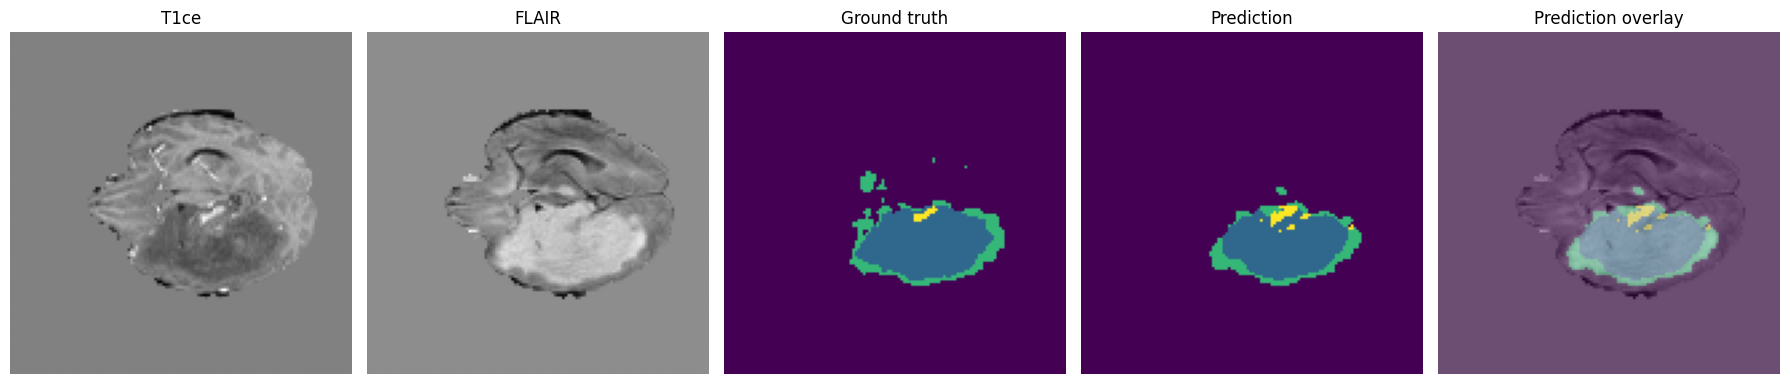

In [31]:
# ============================================================
# VISUALIZE A SEGMENTATION OF THE TRAINED MODEL
# ============================================================

def show_segmentation_result(
    model,
    generator,
    batch_idx=0,
    item_idx=0
):
    x, y_true = generator[batch_idx]

    probabilities = model.predict(
        x,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=-1
    )

    image = x[item_idx]
    true_mask = y_true[item_idx]
    pred_mask = y_pred[item_idx]

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(image[:, :, 1], cmap="gray")
    plt.title("T1ce")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(image[:, :, 3], cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(
        true_mask,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(
        pred_mask,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(image[:, :, 3], cmap="gray")
    plt.imshow(
        pred_mask,
        cmap="viridis",
        alpha=0.45,
        vmin=0,
        vmax=3
    )
    plt.title("Prediction overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

if(execute_train or load_weights):
  show_segmentation_result(model,test_generator,batch_idx=5,item_idx=0)
else:
  print("No visualization available - no training - no loaded weights")

# Model comparison (U-net vs DeepLabv3+)

In [37]:
# ============================================================
# LOAD BEST U-NET AND DEEPLABV3+ MODELS
# ============================================================
UNET_WEIGHTS_URL = "https://drive.google.com/file/d/1k91QoCbnZui53fqXeczM_3pDVvGtamUO/view?usp=drive_link"
UNET_WEIGHTS_PATH = "/content/best_unet.weights.h5"
DEEPLAB_WEIGHTS_URL = "https://drive.google.com/file/d/1cyePZdz9cJInTnEvLRqXu84hBXnB4xWS/view?usp=sharing"
DEEPLAB_WEIGHTS_PATH = "/content/deeplab_best.weights.h5"
gdown.download(UNET_WEIGHTS_URL,UNET_WEIGHTS_PATH,fuzzy=True,quiet=False)
gdown.download(DEEPLAB_WEIGHTS_URL,DEEPLAB_WEIGHTS_PATH,fuzzy=True,quiet=False)

# build modes
best_unet = build_unet()
best_unet.load_weights(UNET_WEIGHTS_PATH)
print("U-Net weights loaded.")
best_deeplab = build_deeplabv3plus()
best_deeplab.load_weights(DEEPLAB_WEIGHTS_PATH)
print("DeepLab weights loaded.")

Downloading...
From: https://drive.google.com/uc?id=1k91QoCbnZui53fqXeczM_3pDVvGtamUO
To: /content/best_unet.weights.h5
100%|██████████| 23.6M/23.6M [00:00<00:00, 74.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cyePZdz9cJInTnEvLRqXu84hBXnB4xWS
To: /content/deeplab_best.weights.h5
100%|██████████| 32.1M/32.1M [00:00<00:00, 84.6MB/s]


U-Net weights loaded.
DeepLab weights loaded.


In [33]:
# ============================================================
# EVALUATE UNET
# ============================================================
unet_metrics = evaluate_model(
    best_unet,
    test_generator
)
print_metrics(
    unet_metrics,
    title="UNET results"
)

Evaluating batch 275/570

KeyboardInterrupt: 

History training of unet model. (*training time : 5h 22m 44s · GPU T4 x2*)  

-------------- ADD PHOTO -----------------

In [38]:
# ============================================================
# EVALUATE DEEPLAB
# ============================================================
deeplab_metrics = evaluate_model(
    best_deeplab,
    test_generator
)
print_metrics(
    deeplab_metrics,
    title="DEEPLAB results"
)

Evaluating batch 570/570

DEEPLAB results
---------------
         ET_dice: 0.7887
          ET_iou: 0.6511
         TC_dice: 0.8416
          TC_iou: 0.7265
         WT_dice: 0.8909
          WT_iou: 0.8033
       mean_dice: 0.8404
        mean_iou: 0.7270
  pixel_accuracy: 0.9949


History training of deeplab model. (*training time : 5h 22m 44s · GPU T4 x2*)

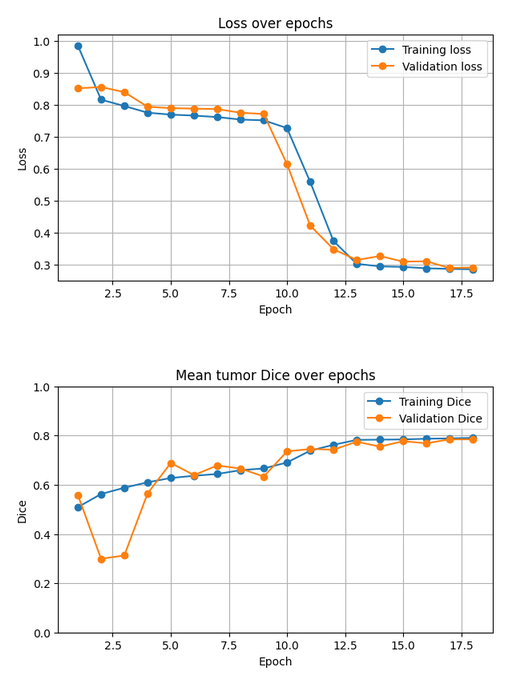

In [ ]:
# ============================================================
# FINAL METRICS COMPARISON TABLE
# U-NET vs DEEPLABV3+
# ============================================================
metric_names = {
    "ET_dice": "ET Dice",
    "ET_iou": "ET IoU",
    "TC_dice": "TC Dice",
    "TC_iou": "TC IoU",
    "WT_dice": "WT Dice",
    "WT_iou": "WT IoU",
    "mean_dice": "Mean Dice",
    "mean_iou": "Mean IoU",
    "pixel_accuracy": "Pixel Accuracy"
}

comparison_data = []

for metric_key, metric_name in metric_names.items():

    unet_value = unet_metrics[metric_key]
    deeplab_value = deeplab_metrics[metric_key]

    comparison_data.append({
        "Metric": metric_name,
        "U-Net": unet_value,
        "DeepLabV3+": deeplab_value,
        "Difference": deeplab_value - unet_value,
        "Best Model": (
            "DeepLabV3+"
            if deeplab_value > unet_value
            else "U-Net"
            if unet_value > deeplab_value
            else "Tie"
        )
    })


comparison_df = pd.DataFrame(comparison_data)

comparison_df.style \
    .format({
        "U-Net": "{:.4f}",
        "DeepLabV3+": "{:.4f}",
        "Difference": "{:+.4f}"
    }) \
    .set_caption("U-Net vs DeepLabV3+ — Test Set Performance") \
    .hide(axis="index")

In [ ]:
# VISUALIZATION SETTINGS
batch_idx=5,
item_idx=0

In [ ]:
# ============================================================
# VISUAL COMPARISON
# U-NET vs DEEPLABV3+
# ============================================================

def compare_segmentation_models(
    model_1,
    model_2,
    generator,
    batch_idx=0,
    item_idx=0,
    model_1_name="U-Net",
    model_2_name="DeepLabV3+"
):

    x, y_true = generator[batch_idx]

    probabilities_1 = model_1.predict(
        x,
        verbose=0
    )

    probabilities_2 = model_2.predict(
        x,
        verbose=0
    )

    y_pred_1 = np.argmax(
        probabilities_1,
        axis=-1
    )

    y_pred_2 = np.argmax(
        probabilities_2,
        axis=-1
    )

    image = x[item_idx]
    true_mask = y_true[item_idx]

    pred_mask_1 = y_pred_1[item_idx]
    pred_mask_2 = y_pred_2[item_idx]

    # --------------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------------

    plt.figure(figsize=(20, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(image[:, :, 1], cmap="gray")
    plt.title("T1ce")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(image[:, :, 3], cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(
        true_mask,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(
        pred_mask_1,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title(f"{model_1_name} Prediction")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(
        pred_mask_2,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title(f"{model_2_name} Prediction")
    plt.axis("off")

    plt.suptitle(
        f"Segmentation Comparison — Batch {batch_idx}, Item {item_idx}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


compare_segmentation_models(
    best_unet,
    best_deeplab,
    test_generator,
    batch_idx=5,
    item_idx=0
)

# Conclusion

Under the same experimental conditions, **DeepLabV3+** achieved better overall segmentation performance than **U-Net**, with higher mean Dice and mean IoU scores. The largest improvement was observed for the Tumor Core, while U-Net remained slightly better on the Enhancing Tumor region. This indicates that DeepLabV3+ provides a modest overall improvement, although the gains are not uniform across all tumor sub-regions.

# References

1. Ronneberger, O., Fischer, P., & Brox, T. (2015).  
   *U-Net: Convolutional Networks for Biomedical Image Segmentation*.  
   In Medical Image Computing and Computer-Assisted Intervention (MICCAI), pp. 234–241.

2. Chen, L.-C., Zhu, Y., Papandreou, G., Schroff, F., & Adam, H. (2018).  
   *Encoder-Decoder with Atrous Separable Convolution for Semantic Image Segmentation*.  
   European Conference on Computer Vision (ECCV), pp. 801–818.

3. Chollet, F. (2017).  
   *Xception: Deep Learning with Depthwise Separable Convolutions*.  
   IEEE Conference on Computer Vision and Pattern Recognition (CVPR), pp. 1251–1258.

4. Hu, J., Shen, L., & Sun, G. (2018).  
   *Squeeze-and-Excitation Networks*.  
   IEEE Conference on Computer Vision and Pattern Recognition (CVPR), pp. 7132–7141.

5. Wu, Y., & He, K. (2018).  
   *Group Normalization*.  
   European Conference on Computer Vision (ECCV), pp. 3–19.

6. Ramachandran, P., Zoph, B., & Le, Q. V. (2017).  
   *Searching for Activation Functions*.  
   arXiv preprint arXiv:1710.05941.

7. Chen, L.-C., Papandreou, G., Schroff, F., & Adam, H. (2017).  
   *Rethinking Atrous Convolution for Semantic Image Segmentation*.  
   arXiv preprint arXiv:1706.05587.